In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import gradio as gr
import warnings

warnings.filterwarnings('ignore')

print("Loading and preprocessing data...")
df = pd.read_csv("corona_tested_006 (2).csv")

# Filter positive/negative
df = df[df['Corona'].isin(['positive', 'negative'])].copy()
df['Corona'] = df['Corona'].map({'positive': 1, 'negative': 0})

# Map the factors that ACTUALLY affect getting the virus: Symptoms
symptom_cols = ['Cough_symptoms', 'Fever', 'Sore_throat', 'Shortness_of_breath', 'Headache']
for col in symptom_cols:
    df[col] = df[col].astype(str).str.lower().map({'true': 1, 'false': 0}).fillna(0).astype(int)

# Map Age and Known Contact (Highly Correlated)
df['Age_60_above'] = df['Age_60_above'].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)
contact_map = {'contact with confirmed': 2, 'abroad': 1, 'other': 0}
df['Known_contact'] = df['Known_contact'].astype(str).str.lower().map(contact_map).fillna(0).astype(int)

# We are removing 'Sex' because it had no significant correlation.
features = symptom_cols + ['Age_60_above', 'Known_contact']
df = df[features + ['Corona']]

print("Data preprocessing complete! Features used:", features)

Loading and preprocessing data...
Data preprocessing complete! Features used: ['Cough_symptoms', 'Fever', 'Sore_throat', 'Shortness_of_breath', 'Headache', 'Age_60_above', 'Known_contact']


In [10]:
print("Splitting data into two separate files...")

# 80% for Training & Validation, 20% for Final Testing
df_train_val, df_final_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Corona'])

df_train_val.to_csv("train_val_data.csv", index=False)
df_final_test.to_csv("final_test_data.csv", index=False)

print("✅ Saved 'train_val_data.csv'")
print("✅ Saved 'final_test_data.csv'")

Splitting data into two separate files...
✅ Saved 'train_val_data.csv'
✅ Saved 'final_test_data.csv'


In [ ]:
print("Loading 'train_val_data.csv' to train the model...")
train_val_data = pd.read_csv("train_val_data.csv")

X_train_val = train_val_data[features]
y_train_val = train_val_data['Corona']

# Split the first file into Training (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Build the Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),  
    Dense(8, activation='relu'),                                    
    Dense(1, activation='sigmoid')                                  
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n🚀 Starting Training Process...")
# Train the model over 20 epochs
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32)

Loading 'train_val_data.csv' to train the model...

🚀 Starting Training Process...
Epoch 1/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9637 - loss: 0.1289 - val_accuracy: 0.9650 - val_loss: 0.1129
Epoch 2/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9667 - loss: 0.1108 - val_accuracy: 0.9671 - val_loss: 0.1113
Epoch 3/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9673 - loss: 0.1103 - val_accuracy: 0.9674 - val_loss: 0.1112
Epoch 4/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9676 - loss: 0.1102 - val_accuracy: 0.9674 - val_loss: 0.1113
Epoch 5/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9676 - loss: 0.1101 - val_accuracy: 0.9660 - val_loss: 0.1112
Epoch 6/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9676 - loss: 0.1100 - val_accuracy: 0.9663 - val_loss: 0.1112
Epoch 7/20
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9677 - loss: 0.1099 - val_accuracy: 0.9672 - val_loss: 0.1109
Epoch 8

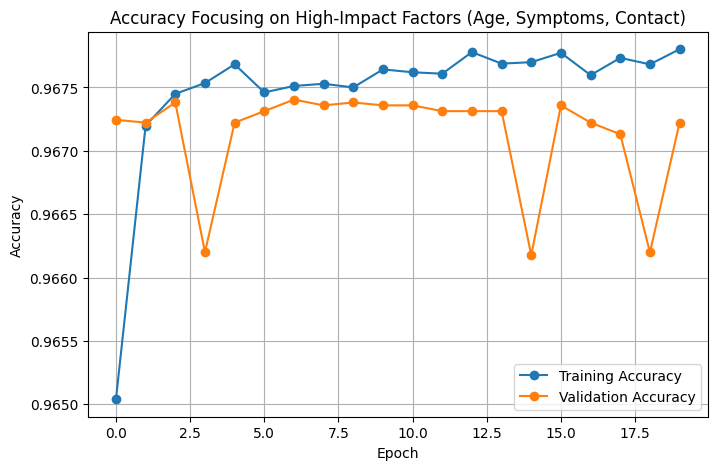

In [ ]:
# Plot the training vs validation accuracy directly in the notebook
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy Focusing on High-Impact Factors (Age, Symptoms, Contact)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
print("Loading 'final_test_data.csv' for the final test...")
test_data = pd.read_csv("final_test_data.csv")

X_final_test = test_data[features]
y_final_test = test_data['Corona']

print("Evaluating on Final Unseen Test Data...")
test_loss, test_accuracy = model.evaluate(X_final_test, y_final_test, verbose=0)

print("\n" + "="*40)
print(f"🎉 FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("="*40)

Loading 'final_test_data.csv' for the final test...
Evaluating on Final Unseen Test Data...

🎉 FINAL TEST ACCURACY: 96.81%


In [ ]:
def predict_corona_nn(cough, fever, sore_throat, shortness_of_breath, headache, age_60, contact):
    
    # Format inputs (No 'Sex' feature anymore)
    input_data = pd.DataFrame({
        'Cough_symptoms': [1 if cough else 0],
        'Fever': [1 if fever else 0],
        'Sore_throat': [1 if sore_throat else 0],
        'Shortness_of_breath': [1 if shortness_of_breath else 0],
        'Headache': [1 if headache else 0],
        'Age_60_above': [1 if age_60 else 0],
        'Known_contact': [2 if contact == 'Contact with confirmed' else (1 if contact == 'Abroad' else 0)]
    }).astype(float) 
    
    # Make prediction
    prob = model.predict(input_data, verbose=0)[0][0]
    probability_percentage = prob * 100
    
    # Output diagnosis
    if prob >= 0.5:
        return f"⚠️ High Likelihood of COVID-19 ({probability_percentage:.1f}% AI Confidence). Please isolate and test."
    else:
        return f"✅ Low Likelihood of COVID-19 ({probability_percentage:.1f}% AI Confidence). Continue to monitor your symptoms."

# UI updated to only ask for the highly correlated factors
inputs = [
    gr.Checkbox(label="Do you have a Cough?"),
    gr.Checkbox(label="Do you have a Fever?"),
    gr.Checkbox(label="Do you have a Sore Throat?"),
    gr.Checkbox(label="Do you experience Shortness of Breath?"),
    gr.Checkbox(label="Do you have a Headache?"),
    gr.Checkbox(label="Are you 60 years or older?"),
    gr.Dropdown(choices=["Other", "Abroad", "Contact with confirmed"], label="Recent Known Contact", value="Other")
]

app = gr.Interface(
    fn=predict_corona_nn, 
    inputs=inputs, 
    outputs=gr.Textbox(label="AI Diagnosis Prediction"), 
    title="🧠 Deep Learning COVID-19 Checker (Optimized)",
    description="This chatbot runs on an optimized Neural Network that focuses purely on high-impact factors like symptoms, age, and exposure history."
)

app.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
